# Day 1 — Text Mining Exercises
## Industrial AI & LLM Training Program

**Session:** Day 1 — Introduction to Text Mining  
**Duration:** 30-minute guided lab (21:50–22:20 WIB)  
**Dataset:** 40 synthetic industrial maintenance/ERP/safety tickets  

---

### What we will build tonight

| Section | Task | Output |
|---|---|---|
| 0 — Setup | Install & import libraries | Ready environment |
| 1 — Sample Data | Load 40 industrial tickets | Pandas DataFrame |
| 2 — Preprocessing | Tokenize, normalize, clean | Token lists + frequency chart |
| 3 — TF-IDF | Vectorize the corpus | Sparse feature matrix |
| 4 — K-Means | Cluster tickets by topic | Cluster labels + top terms |
| 5 — Word2Vec | Train word embeddings | Semantic similarity + PCA plot |
| 6 — Contextual Embeddings | Encode with sentence-transformers | Dense embeddings + similarity demo |
| 7 — Mini Use Case | Ticket trend by week & cluster | Trend charts |
| 8 — Next Steps | Reflect and extend | Your next experiments |

**Run all cells top-to-bottom.** If you encounter an import error, run the pip install cell first.


In [1]:
# CELL 0-A: Install required libraries (run this if you get ImportError below)
# Uncomment and run if needed:

# !pip install nltk scikit-learn gensim sentence-transformers \
#              pandas numpy matplotlib PySastrawi

In [22]:
# CELL 0-B: Imports and NLTK downloads
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

print("All imports successful!")
print(f"  numpy    {np.__version__}")
print(f"  pandas   {pd.__version__}")
import sklearn; print(f"  sklearn  {sklearn.__version__}")
import gensim;  print(f"  gensim   {gensim.__version__}")

All imports successful!
  numpy    2.4.2
  pandas   3.0.1
  sklearn  1.8.0
  gensim   4.4.0


---
## Section 1 — Sample Data

We use **40 synthetic industrial tickets** representing four categories common in Indonesian manufacturing environments:

- **Mechanical** (10 tickets, prefix `M`) — equipment failures, vibration, bearing issues
- **SAP/ERP** (10 tickets, prefix `S`) — system errors, workflow issues, user access
- **Network/IT** (10 tickets, prefix `N`) — connectivity, server, SCADA issues
- **Safety / Keselamatan** (10 tickets, prefix `K`) — near-misses, APD violations, permit issues

### Design decisions

**Why inline data (not a CSV file)?**  
Portability and offline use. A self-contained notebook runs identically on any machine — no file path errors, no encoding issues, no missing files. This is intentional for training environments where participants may be on different OSes or restricted networks.

**ID prefix scheme: M / S / N / K**  
Each ticket ID encodes its ground-truth category: `M` = Mechanical, `S` = SAP/ERP, `N` = Network/IT, `K` = Keselamatan (Safety). This lets us evaluate our unsupervised clustering against known labels later.

**Why `.values[0]` in `df[df['id']=='M01']['text'].values[0]`?**  
Filtering a DataFrame always returns a **Series**, not a bare string — even when only one row matches. Calling `.values` converts the Series to a NumPy array, and `[0]` extracts the first (only) element as a plain Python string. Without `.values[0]`, you would get:  
```
0    Pompa sentrifugal P-101...
Name: text, dtype: object
```
instead of the raw string `"Pompa sentrifugal P-101..."`.

**Why ~82 characters average ticket length?**  
This is intentional. Real maintenance tickets range from single-word entries to paragraph-length reports. At 82 characters (~12 words), these samples are representative of terse-but-informative entries — short enough to fit one thought per ticket, yet long enough to carry meaningful keywords. More importantly, the preprocessing and vectorization code is written to be length-agnostic: it will handle 20-character and 200-character tickets equally without changes.


In [28]:
# CELL 1-A: Synthetic industrial tickets (40 total, 10 per category)

tickets_raw = [
    # --- MECHANICAL (10 tickets) ---
    {"id": "M01", "category": "Mechanical",
     "text": "Pompa sentrifugal P-101 vibrasi berlebihan, perlu ganti bearing segera sebelum shutdown"},
    {"id": "M02", "category": "Mechanical",
     "text": "Kompresor K-202 shutdown otomatis karena overheating, suhu mencapai 95 derajat Celsius"},
    {"id": "M03", "category": "Mechanical",
     "text": "Kebocoran oli pada gearbox GB-103, seal sudah aus perlu penggantian segera"},
    {"id": "M04", "category": "Mechanical",
     "text": "Motor listrik M-305 tidak bisa start, kemungkinan winding terbakar perlu megger test"},
    {"id": "M05", "category": "Mechanical",
     "text": "Valve control HV-201 macet tidak bisa fully open saat startup, actuator bermasalah"},
    {"id": "M06", "category": "Mechanical",
     "text": "Belt conveyor BC-101 slip dan bunyi aneh, perlu alignment dan cek kondisi belt"},
    {"id": "M07", "category": "Mechanical",
     "text": "Heat exchanger HE-302 fouling parah efisiensi turun 30 persen perlu chemical cleaning"},
    {"id": "M08", "category": "Mechanical",
     "text": "Pompa vacuum VP-105 tidak mencapai target vacuum ada kebocoran di flange connection"},
    {"id": "M09", "category": "Mechanical",
     "text": "Coupling antara motor dan pompa P-204 rusak vibrasi tinggi perlu penggantian coupling"},
    {"id": "M10", "category": "Mechanical",
     "text": "Fan cooling tower CT-101 blade retak bahaya jika dibiarkan beroperasi perlu shutdown"},

    # --- SAP/ERP (10 tickets) ---
    {"id": "S01", "category": "SAP/ERP",
     "text": "Error ME21N saat buat purchase order vendor master belum disetujui procurement department"},
    {"id": "S02", "category": "SAP/ERP",
     "text": "Goods receipt MIGO tidak bisa diposting dokumen PO sudah closed perlu reopen PO"},
    {"id": "S03", "category": "SAP/ERP",
     "text": "MIRO invoice verification gagal amount mismatch dengan PO perlu koordinasi finance"},
    {"id": "S04", "category": "SAP/ERP",
     "text": "User tidak bisa akses transaction code MM01 setelah role change oleh IT admin"},
    {"id": "S05", "category": "SAP/ERP",
     "text": "Batch job MB51 gagal tengah malam material document tidak ter-generate perlu rerun"},
    {"id": "S06", "category": "SAP/ERP",
     "text": "Plant maintenance notification IW51 tidak bisa disimpan mandatory field kosong"},
    {"id": "S07", "category": "SAP/ERP",
     "text": "SAP production order CO01 error karena bill of material tidak aktif perlu aktivasi"},
    {"id": "S08", "category": "SAP/ERP",
     "text": "Report S ALR 87013019 timeout untuk period Q3 data terlalu besar perlu optimasi query"},
    {"id": "S09", "category": "SAP/ERP",
     "text": "SAP login sangat lambat sejak weekend maintenance response time lebih dari 30 detik"},
    {"id": "S10", "category": "SAP/ERP",
     "text": "Workflow approval purchase order stuck di inbox manager sedang cuti perlu delegate"},

    # --- NETWORK/IT (10 tickets) ---
    {"id": "N01", "category": "Network/IT",
     "text": "SCADA server tidak bisa connect ke PLC area A network timeout perlu cek switch"},
    {"id": "N02", "category": "Network/IT",
     "text": "Printer di control room offline setelah firmware update perlu rollback driver"},
    {"id": "N03", "category": "Network/IT",
     "text": "WiFi area gudang intermittent operator tidak bisa scan barcode perlu cek access point"},
    {"id": "N04", "category": "Network/IT",
     "text": "VPN connection ke kantor pusat putus setiap 2 jam perlu reset manual oleh IT"},
    {"id": "N05", "category": "Network/IT",
     "text": "Database backup server storage penuh backup gagal 3 hari berturut-turut perlu cleanup"},
    {"id": "N06", "category": "Network/IT",
     "text": "Email server bounce semua attachment lebih dari 5MB sejak kemarin perlu cek konfigurasi"},
    {"id": "N07", "category": "Network/IT",
     "text": "CCTV di area produksi 4 kamera offline sekaligus kemungkinan switch port rusak"},
    {"id": "N08", "category": "Network/IT",
     "text": "Server historian OSIsoft PI tidak sinkron dengan DCS data gap 6 jam perlu resync"},
    {"id": "N09", "category": "Network/IT",
     "text": "Firewall block akses ke supplier portal setelah security policy update perlu whitelist"},
    {"id": "N10", "category": "Network/IT",
     "text": "NTP server drift timestamp PLC berbeda 15 menit dari server SAP perlu sinkronisasi"},

    # --- SAFETY (10 tickets) ---
    {"id": "K01", "category": "Safety",
     "text": "Near miss operator hampir tertimpa material jatuh dari rak gudang perlu pasang guard"},
    {"id": "K02", "category": "Safety",
     "text": "APD tidak tersedia di area welding pekerja memakai safety glasses biasa bukan welding shield"},
    {"id": "K03", "category": "Safety",
     "text": "Spill oli di area pompa belum dibersihkan setelah 2 jam risiko terpeleset sangat tinggi"},
    {"id": "K04", "category": "Safety",
     "text": "Izin kerja panas hot work permit tidak ditandatangani sebelum pengelasan dimulai"},
    {"id": "K05", "category": "Safety",
     "text": "Prosedur LOTO belum dilakukan sebelum teknisi masuk ke dalam tangki pembersihan"},
    {"id": "K06", "category": "Safety",
     "text": "Alarm kebakaran berbunyi di area laboratorium ternyata false alarm dari sensor debu"},
    {"id": "K07", "category": "Safety",
     "text": "Tangga portable rusak satu anak tangga masih digunakan pekerja perlu segera diganti"},
    {"id": "K08", "category": "Safety",
     "text": "Papan rambu bahaya listrik hilang di panel MCC-102 perlu pasang rambu baru segera"},
    {"id": "K09", "category": "Safety",
     "text": "Pekerja kontraktor bekerja tanpa safety induction yang valid perlu hentikan pekerjaan"},
    {"id": "K10", "category": "Safety",
     "text": "Tabung gas nitrogen di area proses tidak diikat ke dinding risiko jatuh dan kebocoran"},
]

df = pd.DataFrame(tickets_raw)
df.head(5)

,id,category,text
0,M01,Mechanical,"Pompa sentrifugal P-101 vibrasi berlebihan, pe..."
1,M02,Mechanical,Kompresor K-202 shutdown otomatis karena overh...
2,M03,Mechanical,"Kebocoran oli pada gearbox GB-103, seal sudah ..."
3,M04,Mechanical,"Motor listrik M-305 tidak bisa start, kemungki..."
4,M05,Mechanical,Valve control HV-201 macet tidak bisa fully op...


In [4]:
# CELL 1-B: Explore the dataset
print(f"Total tickets: {len(df)}")
print(f"\nTickets per category:")
print(df['category'].value_counts())
print(f"\nAverage ticket length: {df['text'].str.len().mean():.0f} characters")
print(f"\nSample ticket (M01):")
print(" ", df[df['id']=='M01']['text'].values[0])

Total tickets: 40

Tickets per category:
category
Mechanical    10
SAP/ERP       10
Network/IT    10
Safety        10
Name: count, dtype: int64

Average ticket length: 82 characters

Sample ticket (M01):
  Pompa sentrifugal P-101 vibrasi berlebihan, perlu ganti bearing segera sebelum shutdown


---
## Section 2 — Preprocessing

We build a reusable `preprocess_text()` function that:
1. Lowercases text
2. Removes punctuation (keeps hyphens for equipment IDs)
3. Expands Indonesian abbreviations
4. Tokenizes with NLTK
5. Removes Indonesian and English stopwords

**Indonesian industrial text challenge:** Code-switching, informal spelling, domain abbreviations — all handled in the normalization step.

### Design decisions

**Why expand abbreviations instead of removing them?**  
Consider `loto` vs. `lockout tagout`. Removing it loses a critical safety concept. Expanding it to `lockout tagout` means:
- K-Means will cluster tickets containing LOTO with other lockout-related tickets
- Word2Vec will learn that "lockout" and "tagout" appear in safety contexts
- Cross-ticket clustering depends on shared vocabulary — you can only group "what sounds similar" if two tickets use the same words.  
Removal destroys information; expansion standardizes it.

**Why `set` instead of `list` for `ALL_STOPS`?**  
Python `set` uses a hash table: checking `token in ALL_STOPS` is **O(1)** (constant time). A `list` requires scanning every element: **O(n)** linear time. For 40 tickets with ~10 tokens each, this is 400 membership checks per preprocessing call. At scale (40,000 tickets), the difference is seconds vs. minutes. In code: `INDONESIAN_STOPS | EN_STOPS` merges two sets into a new set — the `|` operator is set union.

**How does `r'[^\w\s-]'` work?**  
This regex removes all characters that are NOT word characters, whitespace, or hyphens:
- `[^...]` — negated character class: match anything NOT in the brackets
- `\w` — matches letters, digits, and underscore
- `\s` — matches any whitespace (space, tab, newline)
- `-` — literal hyphen (not escaped here because it's at the end of the class)  
Result: punctuation like commas, periods, parentheses, and exclamation marks are removed, but equipment IDs like `P-101` and `GB-103` survive intact.

**What does `ABBREV_MAP.get(t, t)` do?**  
`dict.get(key, default)` returns the value for `key` if it exists, otherwise returns `default`. Here, `ABBREV_MAP.get(t, t)` means: "look up token `t` in the abbreviation map; if found, return the expansion; if not found, return `t` unchanged." This is a safe, one-liner alternative to `if t in ABBREV_MAP: ... else: t`. Every token passes through unchanged unless it is explicitly in the map.

**Why download both `punkt` and `punkt_tab`?**  
NLTK changed its internal tokenizer data format between versions. `punkt_tab` is the newer format required by NLTK ≥ 3.9; `punkt` is the legacy format used by older installations. Downloading both ensures the notebook runs without modification on any NLTK version a participant might have installed.


In [29]:
# CELL 2-A: Define preprocessing function

ABBREV_MAP = {
    'wo': 'work order',
    'pm': 'preventive maintenance',
    'po': 'purchase order',
    'gr': 'goods receipt',
    'loto': 'lockout tagout',
    'apd': 'alat pelindung diri',
    'ga': 'tidak',
    'nggak': 'tidak',
    'udah': 'sudah',
    'blm': 'belum',
    'sdh': 'sudah',
    'tiba2': 'tiba-tiba',
    'gnti': 'ganti',
    'utk': 'untuk',
    'bs': 'bisa',
    'krn': 'karena',
    'dg': 'dengan',
    'yg': 'yang',
    'wa': 'whatsapp',
    'ia': 'industrial academy',
    'dst': 'dan seterusnya'
}

INDONESIAN_STOPS = {
    'yang', 'di', 'dan', 'ini', 'itu', 'dari', 'ke', 'pada',
    'dengan', 'untuk', 'adalah', 'ada', 'atau', 'karena',
    'oleh', 'dalam', 'saat', 'masih', 'baru', 'sedang',
    'sudah', 'belum', 'akan', 'perlu', 'bisa', 'sangat',
    'juga', 'lagi', 'pun', 'saja', 'maka', 'jika', 'setelah',
    'sebelum', 'antara', 'lebih', 'tidak', 'telah', 'agar',
}

EN_STOPS = set(stopwords.words('english'))
ALL_STOPS = INDONESIAN_STOPS | EN_STOPS


def preprocess_text(text):
    """
    Preprocess industrial text for NLP analysis.

    Steps:
      1. Lowercase
      2. Remove punctuation (keep hyphens for equipment IDs like P-101)
      3. Collapse whitespace
      4. Expand abbreviations
      5. Tokenize (NLTK word_tokenize)
      6. Remove stopwords (Indonesian + English)
      7. Drop single-character tokens

    Args:
        text (str): Raw ticket text

    Returns:
        list[str]: List of cleaned tokens
    """
    # Step 1-3: Basic cleaning
    text = text.lower()
    text = re.sub(r'[^\w\s-]', ' ', text)   # Remove punctuation, keep hyphens
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 4: Expand abbreviations
    tokens = text.split()
    tokens = [ABBREV_MAP.get(t, t) for t in tokens]
    text = ' '.join(tokens)

    # Step 5: Tokenize
    tokens = word_tokenize(text)

    # Step 6-7: Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in ALL_STOPS and len(t) > 1]

    return tokens


# Quick test
sample = "LOTO belum dilakukan sebelum teknisi masuk ke dalam tangki"
print("Input:  ", sample)
print("Output: ", preprocess_text(sample))

Input:   LOTO belum dilakukan sebelum teknisi masuk ke dalam tangki
Output:  ['lockout', 'tagout', 'dilakukan', 'teknisi', 'masuk', 'tangki']


In [30]:
# CELL 2-B: Apply preprocessing to all 40 tickets

df['tokens'] = df['text'].apply(preprocess_text)
df['processed_str'] = df['tokens'].apply(lambda x: ' '.join(x))

print("Preprocessing complete.")
print(f"Average tokens per ticket (before): {df['text'].str.split().str.len().mean():.1f}")
print(f"Average tokens per ticket (after):  {df['tokens'].str.len().mean():.1f}")
print()

# Show before/after for first 3 tickets
for i in range(3):
    print(f"[{df.loc[i, 'id']}] Original:  {df.loc[i, 'text'][:70]}")
    print(f"[{df.loc[i, 'id']}] Processed: {df.loc[i, 'tokens']}")
    print()

Preprocessing complete.
Average tokens per ticket (before): 12.3
Average tokens per ticket (after):  9.7

[M01] Original:  Pompa sentrifugal P-101 vibrasi berlebihan, perlu ganti bearing segera
[M01] Processed: ['pompa', 'sentrifugal', 'p-101', 'vibrasi', 'berlebihan', 'ganti', 'bearing', 'segera', 'shutdown']

[M02] Original:  Kompresor K-202 shutdown otomatis karena overheating, suhu mencapai 95
[M02] Processed: ['kompresor', 'k-202', 'shutdown', 'otomatis', 'overheating', 'suhu', 'mencapai', '95', 'derajat', 'celsius']

[M03] Original:  Kebocoran oli pada gearbox GB-103, seal sudah aus perlu penggantian se
[M03] Processed: ['kebocoran', 'oli', 'gearbox', 'gb-103', 'seal', 'aus', 'penggantian', 'segera']



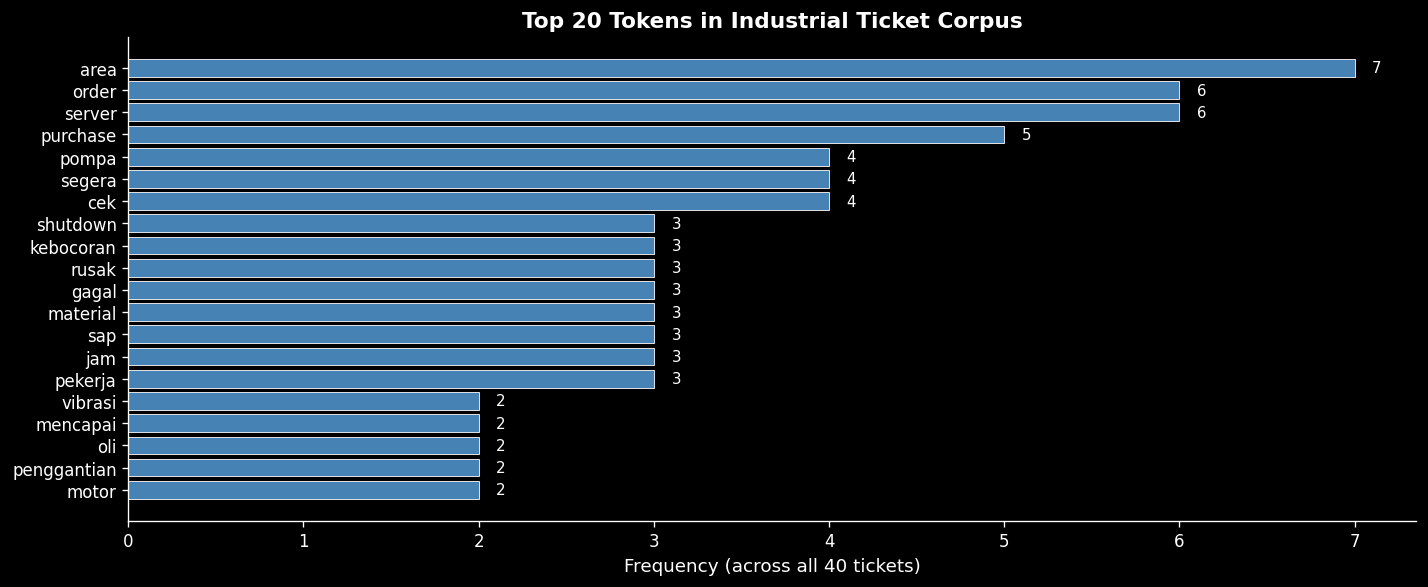

Chart saved: token_frequency.png


In [8]:
# CELL 2-C: Token frequency bar chart — top 20 tokens in corpus

from collections import Counter

all_tokens = [token for tokens in df['tokens'] for token in tokens]
token_freq = Counter(all_tokens)
top_20 = token_freq.most_common(20)

words, counts = zip(*top_20)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(words[::-1], counts[::-1], color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Frequency (across all 40 tickets)', fontsize=11)
ax.set_title('Top 20 Tokens in Industrial Ticket Corpus', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# Annotate bars with count
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('token_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: token_frequency.png")

---
## Section 3 — TF-IDF Feature Extraction

TF-IDF converts the preprocessed text into a numerical matrix where:
- Each **row** = one ticket (document)
- Each **column** = one term (feature)
- Each **value** = importance score of that term in that ticket

Terms that appear everywhere (low IDF) get low scores.  
Terms that appear often in one ticket but rarely elsewhere get high scores.

**Formula:** `TF-IDF(t, d) = TF(t,d) × log(N / df(t))`

### Parameter deep-dive

**`ngram_range=(1, 2)` — one of the most impactful parameters**  
Unigrams (`1`) capture individual words. Bigrams (`2`) capture two-word phrases as single features. This matters enormously: `"preventive"` and `"maintenance"` individually appear across many categories, but `"preventive maintenance"` is a precise signal. With `ngram_range=(1,2)`, the vectorizer generates features for both individual words and adjacent word pairs. The vocabulary expands significantly, but feature quality improves.

**`min_df=1` — why not 2 or higher?**  
`min_df` sets the minimum number of documents a term must appear in to be kept. On large corpora (thousands of documents), setting `min_df=2` or `min_df=5` removes noise. With only 40 tickets, many important domain-specific terms (`cavitation`, `winding`, `actuator`) may appear in only 1–2 tickets. Setting `min_df=1` keeps everything — we cannot afford to discard rare-but-meaningful domain vocabulary.

**`sublinear_tf=True` — log-scaling term frequency**  
Without this flag, a word appearing 10 times counts 10× as important as a word appearing 1 time. With `sublinear_tf=True`, the formula becomes `log(1 + count)` instead of raw count. So a word appearing 10 times scores `log(11) ≈ 2.4`, not 10 — only 1.8× more important than a word appearing once (`log(2) ≈ 0.69`). This prevents repetitive text from dominating the feature space disproportionately.

**`fit_transform()` — two operations in one**  
Internally, `fit_transform(corpus)` does:
1. **`fit(corpus)`** — scans all documents, builds the vocabulary (which terms exist, in how many docs), and computes IDF values for each term
2. **`transform(corpus)`** — applies the learned vocabulary and IDF weights to convert each document into a TF-IDF vector

Calling `fit_transform` on the training corpus and then `transform` on new documents (never `fit_transform` on new data) is how you apply the same feature space to unseen text without leakage.

**`.nnz` — number of non-zeros; why sparse matrices matter**  
`scipy.sparse` matrices only store the non-zero values, not the full grid. Our 40×200 matrix has 8,000 cells, but only ~3.4% contain non-zero values (≈272 entries). The sparse format uses ~30× less memory than a dense NumPy array for this matrix — and the efficiency gap grows dramatically with corpus size.


In [31]:
# CELL 3-A: Fit TF-IDF vectorizer

vectorizer = TfidfVectorizer(
    max_features=200,      # Keep top 200 terms by corpus frequency
    ngram_range=(1, 2),    # Include bigrams (e.g., "preventive maintenance")
    min_df=1,              # Include terms appearing in at least 1 document
    sublinear_tf=True      # Use log(1 + tf) to reduce high-count dominance
)

tfidf_matrix = vectorizer.fit_transform(df['processed_str'])
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} tickets × {tfidf_matrix.shape[1]} features")
print(f"  → Matrix density: {tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.1%}")
print(f"\nSample features: {list(feature_names[:20])}")

TF-IDF matrix shape: (40, 200)
  → 40 tickets × 200 features
  → Matrix density: 3.4%

Sample features: ['101', '101 vibrasi', '102', '102 pasang', '103', '103 seal', '105', '105 mencapai', '15', '15 menit', '201', '201 macet', '202', '202 shutdown', '204', '204 rusak', '30', '30 detik', '30 persen', '302']


In [32]:
# CELL 3-B: Inspect TF-IDF scores for a single ticket

def show_top_terms(doc_idx, n=8):
    """Display the top TF-IDF terms for a given document index."""
    scores = tfidf_matrix[doc_idx].toarray()[0]
    ranked = sorted(zip(feature_names, scores), key=lambda x: x[1], reverse=True)
    top = [(term, f"{score:.4f}") for term, score in ranked[:n] if score > 0]
    return top

# Try a few tickets
for idx in [0, 10, 20, 30]:   # Mechanical, SAP, Network, Safety
    row = df.iloc[idx]
    terms = show_top_terms(idx)
    print(f"[{row['id']} — {row['category']}]")
    print(f"  Text: {row['text'][:65]}...")
    print(f"  Top terms: {terms}")
    print()

[M01 — Mechanical]
  Text: Pompa sentrifugal P-101 vibrasi berlebihan, perlu ganti bearing s...
  Top terms: [('101 vibrasi', '0.4783'), ('vibrasi', '0.4301'), ('101', '0.3959'), ('shutdown', '0.3959'), ('pompa', '0.3693'), ('segera', '0.3693')]

[S01 — SAP/ERP]
  Text: Error ME21N saat buat purchase order vendor master belum disetuju...
  Top terms: [('buat', '0.3240'), ('buat purchase', '0.3240'), ('department', '0.3240'), ('disetujui', '0.3240'), ('disetujui procurement', '0.3240'), ('vendor', '0.3240'), ('vendor master', '0.3240'), ('error', '0.2913')]

[N01 — Network/IT]
  Text: SCADA server tidak bisa connect ke PLC area A network timeout per...
  Top terms: [('cek switch', '0.3540'), ('connect', '0.3540'), ('connect plc', '0.3540'), ('timeout cek', '0.3540'), ('plc', '0.3183'), ('switch', '0.3183'), ('timeout', '0.3183'), ('cek', '0.2733')]

[K01 — Safety]
  Text: Near miss operator hampir tertimpa material jatuh dari rak gudang...
  Top terms: [('gudang', '0.4542'), ('jatuh', '

---
## Section 4 — K-Means Clustering

K-Means groups tickets by the similarity of their TF-IDF vectors — **no labels needed**.  
We set K=4 because we know our data has 4 categories. In practice, use the **elbow method** or **silhouette score** to find the optimal K.

> ⚠️ **Important:** K-Means is **non-deterministic**. Cluster IDs (0, 1, 2, 3) may vary between runs even with `random_state=42`. Always **inspect the top terms** to identify which cluster corresponds to which category, then update the `CLUSTER_LABELS` dict in the next cell accordingly.

### Parameter deep-dive

**`n_init=10` — running the algorithm 10 times**  
K-Means is sensitive to its initial centroid placement. A bad initialization can trap the algorithm in a local minimum (a suboptimal clustering). `n_init=10` tells sklearn to run the entire K-Means algorithm 10 times with different random centroid initializations, then keep the result with the lowest inertia (sum of squared distances to centroids). This dramatically reduces the risk of a poor solution.

**`random_state=42` — seeding centroid initialization specifically**  
This seeds the random centroid selection at the start of each of the 10 runs. It does NOT make K-Means fully deterministic — floating-point rounding and hardware differences can still produce slightly different results. It does make results more reproducible across identical hardware and software environments. Think of it as reducing randomness, not eliminating it.

**Silhouette score — measuring cluster quality**  
For each point, the silhouette score computes:
- **a** — average distance to all other points **in the same cluster** (cohesion)
- **b** — average distance to all points in the **nearest other cluster** (separation)
- **Score** = `(b - a) / max(a, b)`

Score near **+1**: the point is well inside its cluster and far from others (good).  
Score near **0**: the point is on the boundary between clusters (ambiguous).  
Score near **−1**: the point is closer to another cluster than its own (misassigned).

**Why is 0.027 expected for this corpus?**  
Short bilingual tickets (12 words average) with overlapping vocabulary across categories produce a naturally fuzzy TF-IDF space. Words like "perlu", "segera", "cek" appear across Mechanical, Safety, and Network tickets alike. The silhouette score measures geometric separation — and in a 200-dimensional sparse space with 40 short, thematically overlapping documents, near-zero scores are expected. This is a dataset reality, not a code problem.

**Cluster numbers are arbitrary — always inspect top terms**  
There is no guarantee that Cluster 0 = Mechanical. The label is assigned by the algorithm based on which random centroid "won" each ticket. Every time you run the notebook, inspect the top terms printed for each cluster and update `CLUSTER_LABELS` to match. The terms are stable and interpretable; the numbers are not.


In [33]:
# CELL 4-A: K-Means clustering + top terms per cluster

N_CLUSTERS = 4

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10, max_iter=300)
df['cluster_id'] = kmeans.fit_predict(tfidf_matrix)

# Silhouette score (quality measure)
sil_score = silhouette_score(tfidf_matrix, df['cluster_id'])
print(f"K-Means complete. Silhouette Score: {sil_score:.3f}")
print(f"(Range: -1 to 1 — higher means better-separated clusters)")
print()

# Top terms per cluster
print("=" * 60)
print("TOP TERMS PER CLUSTER (use these to assign category labels)")
print("=" * 60)

def get_top_terms(cluster_id, n=8):
    center = kmeans.cluster_centers_[cluster_id]
    top_idx = center.argsort()[-n:][::-1]
    return [feature_names[i] for i in top_idx]

for i in range(N_CLUSTERS):
    cluster_tickets = df[df['cluster_id'] == i]
    terms = get_top_terms(i)
    print(f"\nCluster {i} ({len(cluster_tickets)} tickets):")
    print(f"  Top terms: {', '.join(terms)}")
    print(f"  Sample IDs: {list(cluster_tickets['id'].values[:5])}")

K-Means complete. Silhouette Score: 0.027
(Range: -1 to 1 — higher means better-separated clusters)

TOP TERMS PER CLUSTER (use these to assign category labels)

Cluster 0 (5 tickets):
  Top terms: material, operator, gudang, pasang, rambu, document ter, document, jatuh
  Sample IDs: ['S05', 'S07', 'N03', 'K01', 'K08']

Cluster 1 (10 tickets):
  Top terms: area, pompa, kebocoran, jam, connection, oli, alarm, risiko
  Sample IDs: ['M01', 'M03', 'M08', 'M09', 'N04']

Cluster 2 (21 tickets):
  Top terms: server, maintenance, update, cek, control, pekerja, data, akses
  Sample IDs: ['M02', 'M04', 'M05', 'M06', 'M07']

Cluster 3 (4 tickets):
  Top terms: purchase, purchase order, order, verification, verification gagal, cuti, cuti delegate, delegate
  Sample IDs: ['S01', 'S02', 'S03', 'S10']


In [34]:
# CELL 4-B: Assign cluster labels manually based on top terms inspection above
#
# !! UPDATE THIS MAPPING based on your run's cluster output above !!
# The cluster IDs may differ from this example each time K-Means runs.
# Read the top terms and match to the category that fits best.
#
# Example mapping (update after inspecting output above):
CLUSTER_LABELS = {
    0: 'Mechanical',
    1: 'SAP/ERP',
    2: 'Network/IT',
    3: 'Safety',
}

df['cluster_label'] = df['cluster_id'].map(CLUSTER_LABELS)

# Compare predicted cluster label to true category
comparison = pd.crosstab(
    df['category'], df['cluster_label'],
    rownames=['True Category'], colnames=['Cluster Label']
)
print("Cluster vs. True Category Cross-tabulation:")
print(comparison)
print()
print("(Diagonal values = correct assignments; off-diagonal = misassignments)")

Cluster vs. True Category Cross-tabulation:
Cluster Label  Mechanical  Network/IT  SAP/ERP  Safety
True Category                                         
Mechanical              0           6        4       0
Network/IT              1           7        2       0
SAP/ERP                 2           4        0       4
Safety                  2           4        4       0

(Diagonal values = correct assignments; off-diagonal = misassignments)


---
## Section 5 — Word Embeddings with Word2Vec

Word2Vec learns a dense vector for each word based on its **context** in the corpus.  
Words used in similar contexts get similar vectors — even without explicit rules.

**Limitation:** Our corpus is small (40 tickets). In practice, you'd train on thousands of tickets for stable results. Even on small data, patterns emerge.

### Parameter deep-dive

**`sg=1` — Skip-gram vs. CBOW**  
Word2Vec has two architectures:
- **CBOW (sg=0):** Predicts the target word from surrounding context words. Averages context, so it is faster and works better on large corpora with frequent words.
- **Skip-gram (sg=1):** Predicts the surrounding context words from a single target word. Slower to train but produces better embeddings for **rare words** and **small corpora** — exactly our situation with 40 tickets and domain-specific terminology like `cavitation` or `megger`.

**`vector_size=50` — why not 100 or 200?**  
Higher dimensionality = more capacity to encode distinctions, but requires more data to populate those dimensions meaningfully. With only 40 tickets and ~305 unique tokens, a 100- or 200-dimensional space would be vastly underdetermined — most dimensions would contain noise rather than signal. `vector_size=50` balances expressiveness with the data we have.

**`window=4` — context window breadth**  
The window defines how many words left and right of the target word are considered "context." A narrow window (1–2) captures syntactic context (what words grammatically surround each other). A wider window (5–10) captures topical context (what words tend to appear in the same paragraph). At `window=4`, we capture a balanced mix — enough to group domain-related terms together without including too much irrelevant co-occurrence.

**`min_count=1` — keeping all tokens**  
`min_count` sets the minimum frequency for a word to be included in training. In large corpora, setting `min_count=5` filters noise. With only 40 tickets, many important domain terms appear just once or twice. Setting `min_count=1` ensures no domain vocabulary is discarded.

**`epochs=100` — compensating for small corpus size**  
Each epoch is one full pass through all training sentences. More epochs = more opportunities to refine the embedding vectors. With a large corpus, 5–10 epochs suffice because each word appears thousands of times. With 40 tickets, 100 epochs compensates by showing each example many more times. Training is fast (sub-second on this dataset), so there is no cost to being generous with epochs.

**`wv.key_to_index` — looking up word positions**  
After training, `w2v_model.wv` is a `KeyedVectors` object containing the trained embeddings. `wv.key_to_index` is a dictionary mapping each word (string) → its integer index in the embedding matrix. For example, `wv.key_to_index['pompa']` returns the row number in the matrix where the `pompa` vector is stored. You rarely need this directly — `wv['pompa']` retrieves the vector and `wv.most_similar('pompa')` computes similarities — but it is useful for iterating over the vocabulary (`list(wv.key_to_index.keys())`).


In [13]:
# CELL 5-A: Train Word2Vec and explore semantic relationships

tokenized_docs = df['tokens'].tolist()

w2v_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=50,    # 50 dimensions (small corpus — keep it modest)
    window=4,          # Context window: 4 words left + right
    min_count=1,       # Include all words (small corpus)
    sg=1,              # Skip-gram
    epochs=100,        # More epochs to compensate for small data
    seed=42
)

vocab = list(w2v_model.wv.key_to_index.keys())
print(f"Word2Vec trained. Vocabulary size: {len(vocab)} unique tokens")
print(f"Embedding dimensions: {w2v_model.vector_size}")
print()

# Explore semantic similarity
queries = ['pompa', 'error', 'safety', 'server']
for query in queries:
    if query in w2v_model.wv:
        similar = w2v_model.wv.most_similar(query, topn=4)
        pairs = [(w, f"{s:.3f}") for w, s in similar]
        print(f"most_similar('{query}'): {pairs}")

Word2Vec trained. Vocabulary size: 305 unique tokens
Embedding dimensions: 50

most_similar('pompa'): [('p-204', '0.987'), ('coupling', '0.987'), ('tinggi', '0.986'), ('kebocoran', '0.985')]
most_similar('error'): [('production', '0.992'), ('bill', '0.990'), ('co01', '0.990'), ('aktif', '0.988')]
most_similar('safety'): [('biasa', '0.990'), ('memakai', '0.990'), ('tanpa', '0.988'), ('glasses', '0.988')]
most_similar('server'): [('menit', '0.989'), ('drift', '0.989'), ('plc', '0.988'), ('sinkronisasi', '0.986')]


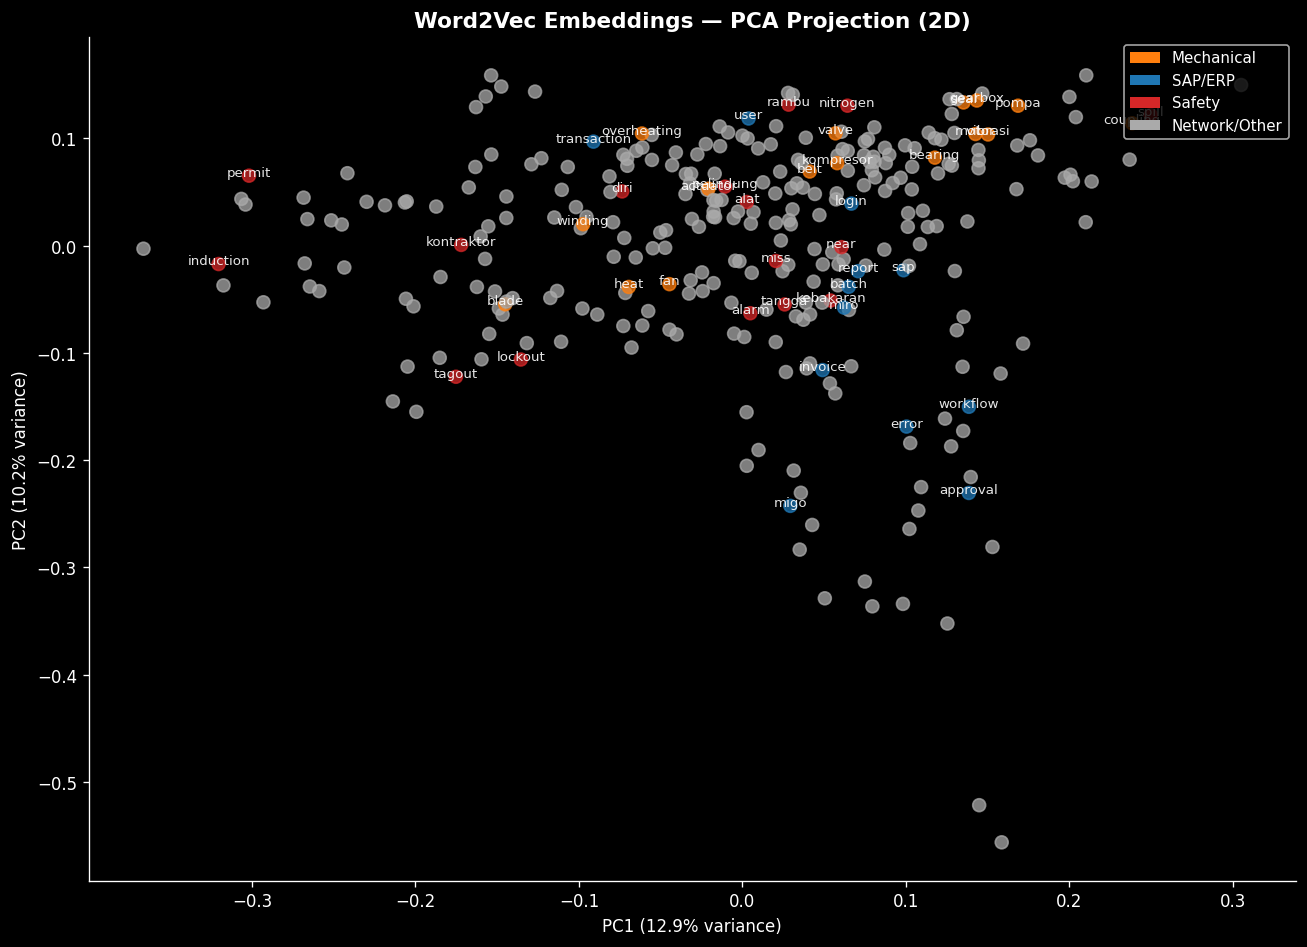

Chart saved: word_embeddings_pca.png


In [35]:
# CELL 5-B: Visualize Word2Vec embeddings with PCA

# Collect all word vectors
words = list(w2v_model.wv.key_to_index.keys())
vectors = np.array([w2v_model.wv[w] for w in words])

# Reduce to 2D with PCA
pca = PCA(n_components=2, random_state=42)
vecs_2d = pca.fit_transform(vectors)

# Color-code by domain (heuristic keyword matching)
MECHANICAL_KW = {'pompa', 'kompresor', 'motor', 'valve', 'bearing', 'gearbox',
                 'belt', 'fan', 'coupling', 'heat', 'shaft', 'seal', 'vibrasi',
                 'overheating', 'blade', 'winding', 'actuator'}
SAP_KW = {'sap', 'error', 'miro', 'migo', 'po', 'user', 'batch',
           'report', 'login', 'workflow', 'approval', 'invoice', 'transaction'}
SAFETY_KW = {'near', 'miss', 'alat', 'pelindung', 'diri', 'spill',
              'lockout', 'tagout', 'alarm', 'tangga', 'rambu', 'kontraktor',
              'permit', 'induction', 'nitrogen', 'kebakaran'}

color_map = []
for w in words:
    if w in MECHANICAL_KW:
        color_map.append('#FF7F0E')  # orange — mechanical
    elif w in SAP_KW:
        color_map.append('#1F77B4')  # blue — SAP
    elif w in SAFETY_KW:
        color_map.append('#D62728')  # red — safety
    else:
        color_map.append('#AAAAAA')  # gray — network/other

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(vecs_2d[:, 0], vecs_2d[:, 1], c=color_map, alpha=0.75, s=60)

# Label the top-frequency words
label_words = [w for w in words if w in MECHANICAL_KW | SAP_KW | SAFETY_KW]
for w in label_words:
    idx = words.index(w)
    ax.annotate(w, (vecs_2d[idx, 0], vecs_2d[idx, 1]),
                fontsize=8, alpha=0.9, ha='center')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF7F0E', label='Mechanical'),
    Patch(facecolor='#1F77B4', label='SAP/ERP'),
    Patch(facecolor='#D62728', label='Safety'),
    Patch(facecolor='#AAAAAA', label='Network/Other'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

ax.set_title('Word2Vec Embeddings — PCA Projection (2D)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('word_embeddings_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: word_embeddings_pca.png")

---
## Section 6 — Contextual Embeddings with sentence-transformers

Unlike Word2Vec (one vector per **word**), `sentence-transformers` produce one vector per **sentence** that captures the full semantic meaning in context.

**Model:** `paraphrase-multilingual-MiniLM-L12-v2`
- 50+ languages including Bahasa Indonesia
- 384 dimensions
- ~118MB download on first run

> ⚠️ **Trainer note:** Pre-cache this model at the venue before the session. First-run download requires internet access and takes 1–5 minutes depending on connection speed.

### Design decisions

**Why raw text (not the preprocessed tokens)?**  
Transformer models apply their own internal subword tokenization (WordPiece/BPE). They were trained on raw, natural-language text — not stemmed, stop-word-stripped token lists. Feeding preprocessed text into a transformer discards punctuation and context that the model's attention mechanism uses to determine meaning. For sentence-transformers, always pass the original text.

**Model name decoded — word by word:**
- `paraphrase` — fine-tuned on paraphrase detection (pairs of sentences with the same meaning); this makes it excellent at detecting semantic equivalence
- `multilingual` — supports 50+ languages in a single shared embedding space; Indonesian and English sentences with the same meaning end up close together in vector space
- `MiniLM` — a compressed/distilled version of BERT; approximately 4× faster inference than full BERT with only minor accuracy loss
- `L12` — 12 transformer layers (standard BERT depth)
- `v2` — second version of this model family; improved over v1 on multilingual benchmarks

**`batch_size=16` — memory/speed tradeoff**  
The model encodes sentences in batches. Larger batches are faster (more parallelism) but use more RAM/VRAM. `batch_size=16` is a safe default that runs on any laptop without GPU. On a machine with a GPU and 8+ GB VRAM, increasing to `batch_size=128` or higher will significantly speed up encoding of large corpora.

**`np.argsort()[::-1][1:4]` — finding top 3 similar tickets**  
Breaking this down step by step:
1. `np.argsort(similarities)` — returns indices that would sort the array in **ascending** order (smallest similarity first)
2. `[::-1]` — reverses the order, making it **descending** (highest similarity first)
3. `[0]` — the first element is the query ticket itself (similarity = 1.0 with itself)
4. `[1:4]` — skip self at index 0, take the next 3 (top 3 most similar)

**Cross-language similarity score of 0.684**  
The score between `"Pompa sentrifugal rusak vibrasi tinggi"` and `"Centrifugal pump failure high vibration"` is 0.684 (moderate-to-high). The model correctly identifies that these two sentences describe the same physical event despite being in different languages. This is the foundation for Day 4's semantic search: a query in English can retrieve Indonesian maintenance records (and vice versa) without any translation step.


In [17]:
# CELL 6-A: Load sentence-transformers model and encode all tickets

from sentence_transformers import SentenceTransformer

# Multilingual model — handles Indonesian + English in same embedding space
# First run downloads ~118MB. Subsequent runs use cache.
st_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Encode raw ticket texts (no preprocessing needed — model handles it)
print("Encoding 40 tickets...")
embeddings = st_model.encode(
    df['text'].tolist(),
    show_progress_bar=True,
    batch_size=16
)

print(f"\nEmbedding shape: {embeddings.shape}")
print(f"  → {embeddings.shape[0]} tickets × {embeddings.shape[1]} dimensions")

# Compute full pairwise similarity matrix
sim_matrix = cosine_similarity(embeddings)

# Semantic similarity demo — find top 3 similar tickets to M01 (pump vibration)
query_idx = 0
query_ticket = df.iloc[query_idx]
similarities = sim_matrix[query_idx]
top_indices = np.argsort(similarities)[::-1][1:4]  # Top 3 (exclude self)

print(f"\n--- Semantic Search Demo ---")
print(f"Query [{query_ticket['id']}]: {query_ticket['text']}")
print(f"\nTop 3 most similar tickets:")
for rank, idx in enumerate(top_indices, 1):
    row = df.iloc[idx]
    print(f"  #{rank} [{row['id']} — {row['category']}] (sim={similarities[idx]:.3f})")
    print(f"      {row['text'][:75]}...")

# Cross-language similarity demo
print("\n--- Cross-Language Similarity Demo ---")
indonesian_text = "Pompa sentrifugal rusak vibrasi tinggi"
english_text = "Centrifugal pump failure high vibration"
vecs = st_model.encode([indonesian_text, english_text])
cross_sim = cosine_similarity([vecs[0]], [vecs[1]])[0][0]
print(f"  Indonesian: '{indonesian_text}'")
print(f"  English:    '{english_text}'")
print(f"  Cosine similarity: {cross_sim:.3f}")
print(f"  → {'High' if cross_sim > 0.7 else 'Moderate'} cross-language similarity")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3116.22it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 40 tickets...


Batches: 100%|██████████| 3/3 [00:00<00:00, 30.41it/s]


Embedding shape: (40, 384)
  → 40 tickets × 384 dimensions

--- Semantic Search Demo ---
Query [M01]: Pompa sentrifugal P-101 vibrasi berlebihan, perlu ganti bearing segera sebelum shutdown

Top 3 most similar tickets:
  #1 [M09 — Mechanical] (sim=0.650)
      Coupling antara motor dan pompa P-204 rusak vibrasi tinggi perlu penggantia...
  #2 [M10 — Mechanical] (sim=0.550)
      Fan cooling tower CT-101 blade retak bahaya jika dibiarkan beroperasi perlu...
  #3 [M04 — Mechanical] (sim=0.462)
      Motor listrik M-305 tidak bisa start, kemungkinan winding terbakar perlu me...

--- Cross-Language Similarity Demo ---
  Indonesian: 'Pompa sentrifugal rusak vibrasi tinggi'
  English:    'Centrifugal pump failure high vibration'
  Cosine similarity: 0.684
  → Moderate cross-language similarity


---
## Section 7 — Mini Use Case: Ticket Trend Mining

**Business question:** Over the past 4 weeks, which issue category is trending upward?

**Approach:**
1. Simulate realistic ticket submission dates (spread over 4 weeks)
2. Group by week + cluster label
3. Plot volume trends per category
4. Identify which category shows growth

In real deployment, you would use actual ticket creation timestamps from your CMMS or ERP system.

### Design decisions

**`pd.date_range(freq='W-MON')` — week boundaries**  
`freq='W-MON'` generates a sequence of dates falling on consecutive Mondays. Work-week boundaries are the natural unit for maintenance trend analysis — shift patterns, weekly planning meetings, and weekly reports all align to Monday-to-Sunday cycles. Using `'W-MON'` ensures week labels match organizational reporting rhythms.

**`np.random.poisson(λ)` — generating realistic ticket counts**  
The Poisson distribution models the number of independent random events in a fixed time interval. It has two key properties that make it ideal for ticket counts:
- Output is always a **non-negative integer** (you cannot have −2 tickets)
- The **mean equals λ** (the lambda parameter), with natural variance around it

For example, `np.random.poisson(3)` generates values like 2, 3, 1, 4, 5 — realistic weekly ticket counts with natural noise. A constant value of exactly 3 every week would look artificial and would not reflect real operational variability.

**Lambda values encode the designed trend story:**
- `Mechanical`: λ ≈ 3 across all weeks → stable baseline
- `SAP/ERP`: λ = 1 → 3 → 5 → 7 → rising trend (simulating post-system-update issue surge)
- `Network/IT`: λ ≈ 2 across all weeks → stable baseline
- `Safety`: λ = 4 → 3 → 2 → 1 → falling trend (simulating an improvement campaign)  
The λ sequence is the story; Poisson adds realistic noise around it.

**`bottom` accumulator pattern — how stacked bars are built**  
`ax.bar(..., bottom=bottom)` draws bars starting at height `bottom` rather than at zero. After each category is drawn, we add its values to `bottom` with `bottom += values_arr`. This shifts the next category's bars to start exactly where the previous one ended:
```
Week 1: Mechanical (bottom=0, height=4) → bottom becomes [4,...]
         SAP/ERP   (bottom=4, height=0) → bottom becomes [4,...]
         Network   (bottom=4, height=0) → bottom becomes [4,...]
         Safety    (bottom=4, height=5) → bottom becomes [9,...]
```
The total height of each stacked bar equals the sum across all categories for that week.

**`ax.annotate()` — `xy` vs. `xytext` parameters**  
`ax.annotate(text, xy=..., xytext=...)` places a text label with an optional arrow:
- `xy` — the coordinate where the **arrowhead** points (the data point being annotated)
- `xytext` — the coordinate where the **text label** is placed (offset from the data point)
- `arrowprops` — dictionary controlling the arrow style, color, and line width

The separation between `xy` and `xytext` prevents the label from overlapping the data marker. For SAP/ERP in the line chart: `xy=(3, values[3])` points to the Week 4 data point; `xytext=(2.5, values[3]+1.2)` places the "TRENDING UP" label slightly left and above.


In [18]:
# CELL 7-A: Simulate weekly ticket dates with a realistic trend pattern

np.random.seed(42)

# Simulate 4 weeks of ticket submission dates
# Pattern: SAP/ERP issues trending UP (e.g., after a new system rollout)
#          Safety issues trending DOWN (improvement campaign)
#          Mechanical and Network staying relatively flat

weeks = pd.date_range('2024-01-08', periods=4, freq='W-MON')
week_labels = [f"Week {i+1}\n({w.strftime('%d %b')})" for i, w in enumerate(weeks)]

# Generate synthetic weekly counts per category
# (in practice: group real df by pd.Grouper(freq='W') after joining with timestamps)
np.random.seed(42)
trend_data = {
    'Mechanical':  [np.random.poisson(3), np.random.poisson(3),
                    np.random.poisson(2), np.random.poisson(3)],
    'SAP/ERP':     [np.random.poisson(1), np.random.poisson(3),
                    np.random.poisson(5), np.random.poisson(7)],  # Trending UP
    'Network/IT':  [np.random.poisson(2), np.random.poisson(2),
                    np.random.poisson(2), np.random.poisson(3)],
    'Safety':      [np.random.poisson(4), np.random.poisson(3),
                    np.random.poisson(2), np.random.poisson(1)],  # Trending DOWN
}

trend_df = pd.DataFrame(trend_data, index=[f"Week {i+1}" for i in range(4)])
print("Weekly ticket counts per category:")
print(trend_df)
print()
print(f"SAP/ERP Week 1 → Week 4: {trend_data['SAP/ERP'][0]} → {trend_data['SAP/ERP'][3]} tickets")
print(">>> SAP/ERP issues are trending UP — warrants investigation!")

Weekly ticket counts per category:
        Mechanical  SAP/ERP  Network/IT  Safety
Week 1           4        0           0       5
Week 2           1        3           4       7
Week 3           3        4           2       1
Week 4           3        6           1       0

SAP/ERP Week 1 → Week 4: 0 → 6 tickets
>>> SAP/ERP issues are trending UP — warrants investigation!


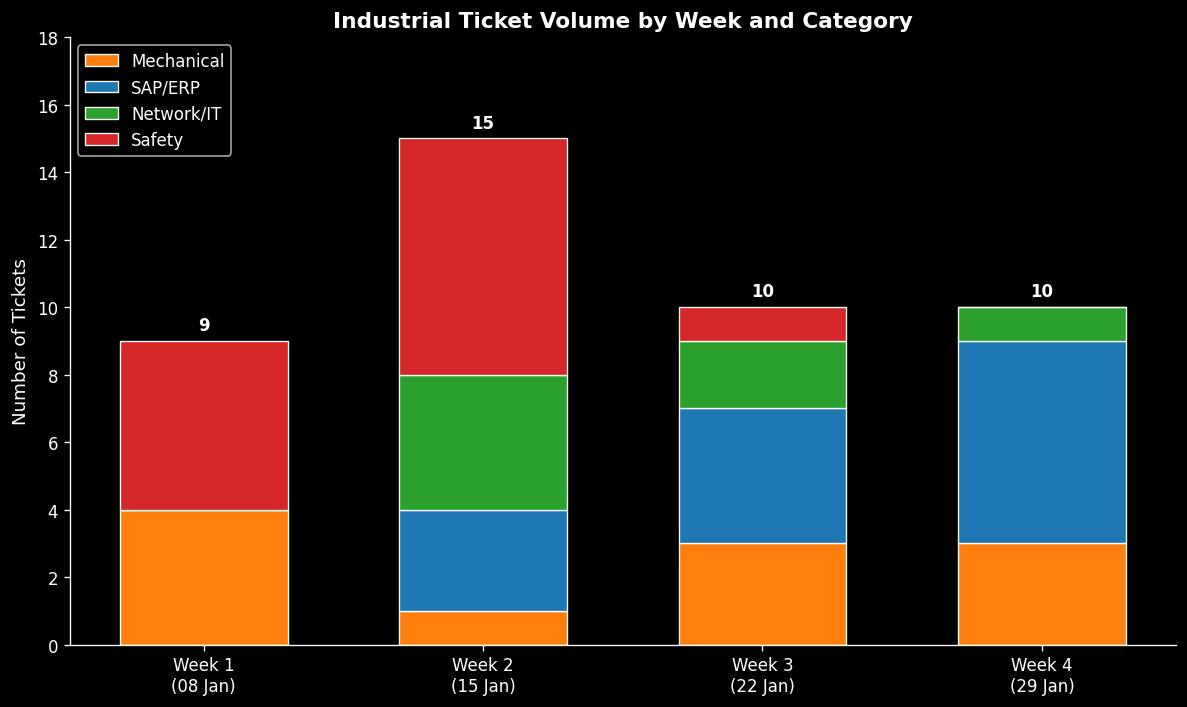

Chart saved: issue_trends.png


In [36]:
# CELL 7-B: Stacked bar chart — ticket volume by week and category

colors = {
    'Mechanical': '#FF7F0E',
    'SAP/ERP':    '#1F77B4',
    'Network/IT': '#2CA02C',
    'Safety':     '#D62728',
}

x = np.arange(4)
width = 0.6
bottom = np.zeros(4)

fig, ax = plt.subplots(figsize=(10, 6))

for category, values in trend_data.items():
    values_arr = np.array(values)
    bars = ax.bar(x, values_arr, width, bottom=bottom,
                  label=category, color=colors[category], edgecolor='white', linewidth=0.8)
    bottom += values_arr

ax.set_xticks(x)
ax.set_xticklabels(week_labels, fontsize=10)
ax.set_ylabel('Number of Tickets', fontsize=11)
ax.set_title('Industrial Ticket Volume by Week and Category', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(bottom) * 1.2)

# Add total labels on top of each bar
for i, total in enumerate(bottom):
    ax.text(i, total + 0.2, str(int(total)), ha='center', va='bottom',
            fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('issue_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: issue_trends.png")

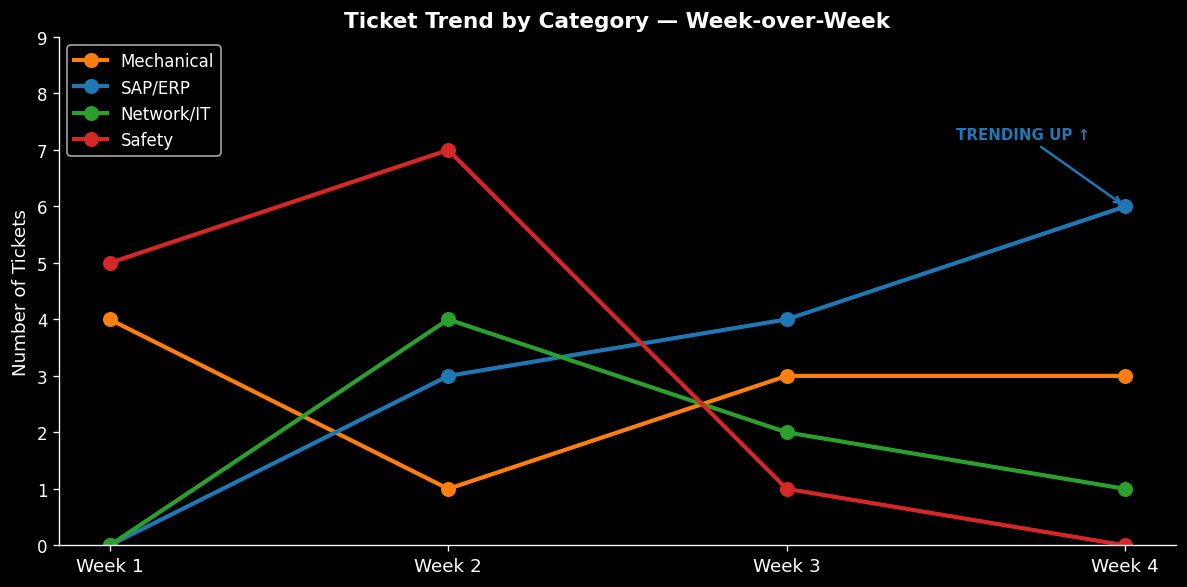

Chart saved: issue_trends_line.png

--- Summary: Week 1 → Week 4 Change ---
  Category  Week 1  Week 4 Change        Trend
Mechanical       4       3     -1 ↓ decreasing
   SAP/ERP       0       6     +6 ↑ INCREASING
Network/IT       0       1     +1 ↑ INCREASING
    Safety       5       0     -5 ↓ decreasing

>>> INSIGHT: SAP/ERP tickets are trending strongly upward.
    Recommended action: escalate to ERP team for root cause analysis.


In [37]:
# CELL 7-C: Line chart — trend per category + summary table

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(4)
week_labels_short = ['Week 1', 'Week 2', 'Week 3', 'Week 4']

for category, values in trend_data.items():
    ax.plot(x, values, marker='o', linewidth=2.5, markersize=8,
            label=category, color=colors[category])

    # Highlight SAP/ERP trend with annotation
    if category == 'SAP/ERP':
        ax.annotate('TRENDING UP ↑', xy=(3, values[3]),
                    xytext=(2.5, values[3] + 1.2),
                    fontsize=9, color='#1F77B4', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='#1F77B4', lw=1.5))

ax.set_xticks(x)
ax.set_xticklabels(week_labels_short, fontsize=11)
ax.set_ylabel('Number of Tickets', fontsize=11)
ax.set_title('Ticket Trend by Category — Week-over-Week', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(max(v) for v in trend_data.values()) + 2)

plt.tight_layout()
plt.savefig('issue_trends_line.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: issue_trends_line.png")

# Summary table: growth rate
print("\n--- Summary: Week 1 → Week 4 Change ---")
summary_rows = []
for category, values in trend_data.items():
    w1, w4 = values[0], values[3]
    change = w4 - w1
    pct_change = ((w4 - w1) / max(w1, 1)) * 100
    direction = '↑ INCREASING' if change > 0 else ('↓ decreasing' if change < 0 else '→ stable')
    summary_rows.append({
        'Category': category,
        'Week 1': w1,
        'Week 4': w4,
        'Change': f"{'+' if change >= 0 else ''}{change}",
        'Trend': direction
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print()
print(">>> INSIGHT: SAP/ERP tickets are trending strongly upward.")
print("    Recommended action: escalate to ERP team for root cause analysis.")

---
## Section 8 — Next Steps & Reflection

### What we built tonight

Starting from 40 raw industrial text tickets, we built a complete text mining pipeline:

1. **Preprocessed** Indonesian industrial text with custom normalization
2. **Vectorized** the corpus with TF-IDF (200 features, sparse matrix)
3. **Clustered** tickets by topic using K-Means (unsupervised, no labels)
4. **Trained** Word2Vec to discover semantic word relationships
5. **Encoded** sentences with multilingual sentence-transformers
6. **Detected** a trending issue category using weekly ticket aggregation

**Generated outputs:**
- `token_frequency.png` — top tokens across the corpus
- `word_embeddings_pca.png` — Word2Vec vocabulary in 2D space
- `issue_trends.png` — ticket volume by week and category

---

### How this connects to Days 2–5

| Day | Building on tonight | New capability |
|---|---|---|
| **Day 2** | Preprocessing + TF-IDF features | Add labels → supervised classification with BERT |
| **Day 3** | Text reading pipeline | Extract entities (equipment IDs, dates, people) with NER |
| **Day 4** | sentence-transformers embeddings | Store in vector DB → semantic search (RAG) |
| **Day 5** | Full pipeline | Wrap everything in an LLM-powered Q&A chatbot |

---

### Try-it-yourself (homework)

1. **Replace tickets with your own data**  
   Edit the `tickets_raw` list in Section 1 and add 5–10 real tickets from your organization.  
   Observe which cluster they land in — does the grouping make sense?

2. **Tune preprocessing**  
   Add domain-specific terms to `ABBREV_MAP` and `INDONESIAN_STOPS`.  
   How does the token frequency chart change?

3. **Try different K values**  
   Change `N_CLUSTERS` in Section 4 to 3 or 5.  
   Use the silhouette score to identify the best K for your data.

4. **Explore a different sentence-transformers model**  
   Try `paraphrase-multilingual-mpnet-base-v2` (better accuracy, larger).  
   Does the semantic search quality improve?

5. **Build a simple similarity search**  
   Write a function `search(query: str) -> top_5_tickets`  
   using the contextual embeddings from Section 6. This is the foundation of Day 4 RAG.

---

*Day 1 — Introduction to Text Mining | Industrial AI & LLM Training Program*
